# Land cover classification at the Mississppi Delta

In this notebook, you will use a k-means **unsupervised** clustering
algorithm to group pixels by similar spectral signatures. **k-means** is
an **exploratory** method for finding patterns in data. Because it is
unsupervised, you don’t need any training data for the model. You also
can’t measure how well it “performs” because the clusters will not
correspond to any particular land cover class. However, we expect at
least some of the clusters to be identifiable as different types of land
cover.

You will use the [harmonized Sentinel/Landsat multispectral
dataset](https://lpdaac.usgs.gov/documents/1698/HLS_User_Guide_V2.pdf).
You can access the data with an [Earthdata
account](https://www.earthdata.nasa.gov/learn/get-started) and the
[`earthaccess` library from
NSIDC](https://github.com/nsidc/earthaccess):

## STEP 1: Set up

### Step 1a: Load libraries and set GDAL parameters

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Import all libraries you will need for this analysis</li>
<li>Configure GDAL parameters to help avoid connection errors:
<code>python      os.environ["GDAL_HTTP_MAX_RETRY"] = "5"      os.environ["GDAL_HTTP_RETRY_DELAY"] = "1"</code></li>
</ol></div></div>

In [ ]:
#+++Libraries for caching decorator and debugging+++#
import os
import pickle
import re
import warnings
from pathlib import Path

#+++Libraries for geospatial work and clustering+++#
#++Note++#
#You will need to install earthaccess in terminal. Below is how to do this#
# conda activate [your environment]
# conda install -c conda-forge earthaccess
# python -c "import earthaccess; print(earthaccess.__version__)"
# my kernel also is missing earthpy so that also was installed in terminal
# do the same steps as above but replace with earthpy

import cartopy.crs as ccrs
import earthaccess
import earthpy as et
import geopandas as gpd
import geoviews as gv
import hvplot.pandas
import hvplot.xarray
import numpy as np
import pandas as pd
import rioxarray as rxr
import rioxarray.merge as rxrmerge
#Note#
# This library specifically gives us spiffy progress bars that you will see later
from tqdm.notebook import tqdm
import xarray as xr
from shapely.geometry import Polygon
from sklearn.cluster import KMeans

### set GDAL parameters
os.environ["GDAL_HTTP_MAX_RETRY"] = "5"
os.environ["GDAL_HTTP_RETRY_DELAY"] = "1"

# Half way through I got tired of debugging warnings. The following will keep warning messages 
# from making our output messy or harder to read
### don't show non-critical warnings
warnings.simplefilter('ignore')


### Step 1b: Run the caching decorator

Below you can find code for a caching **decorator** which you can use in
your code. To use the decorator:

``` python
@cached(key, override)
def do_something(*args, **kwargs):
    ...
    return item_to_cache
```

This decorator will **pickle** the results of running the
`do_something()` function, and only run the code if the results don’t
already exist. To override the caching, for example temporarily after
making changes to your code, set `override=True`. Note that to use the
caching decorator, you must write your own function to perform each
task!

You might notice that typically in these assignments, we start by creating a data_dir to store our data files. Here, our caching decorator is making the data directory for us.

### What my code is doing

In this step, I define a caching decorator that saves the output of computationally intensive functions to disk. This allows me to avoid re-running expensive operations (such as downloading and processing satellite data) every time the notebook is executed. Despite this you may run into some cache issues like I did later in the notebook. Keep in mind that when caching, if you cache an empty array or dataframe you will keep calling the empty data unless you fix (or delete) the cache. 

When the function is called again with the same inputs, the cached result is loaded instead of recomputing everything. This is especially useful when working with remote sensing data, which can take several minutes to process. Depending on how big your watershed is, the time to complete the functions later should ideally be no longer than 10 minutes. 

In [ ]:
### make the caching decorator
## some of the items here are to insure when we rerun cache cells we don't redo our work
def cached(func_key, override=False):
    """
    A decorator to cache function results
    
    Parameters
    ==========
    key: str
      File basename used to save pickled results
    override: bool
      When True, re-compute even if the results are already stored
    """
    def compute_and_cache_decorator(compute_function):
        """
        Wrap the caching function
        
        Parameters
        ==========
        compute_function: function
          The function to run and cache results
        """
        def compute_and_cache(*args, **kwargs):
            """
            Perform a computation and cache, or load cached result.
            
            Parameters
            ==========
            args
              Positional arguments for the compute function
            kwargs
              Keyword arguments for the compute function
            """
            ### Add an identifier from the particular function call
            if 'cache_key' in kwargs:
                key = '_'.join((func_key, kwargs['cache_key']))
            else:
                key = func_key

            ### define a file path based on the directory structure in earthpy
            path = os.path.join(
                
                ### earthpy directory
                et.io.HOME, 
                
                ### earthpy dataset
                et.io.DATA_NAME, 
                
                ### make a subdirectory called "jars"
                'jars', 
                
                ### use f-string (formatted string) to create a string by embedding the value
                ### of the variable "key" into the string 
                ### use .pickle file extension (a pickle file is a serialized python objecT)
                f'{key}.pickle')
            
            ### Check if the cache exists already or if we should override caching
            if not os.path.exists(path) or override:
                
                ### Make jars directory if needed
                os.makedirs(os.path.dirname(path), exist_ok=True)
                
                ### Run the compute function as the user did
                result = compute_function(*args, **kwargs)
                
                ### Pickle the object (save to file)
                ### open the file at filename
                with open(path, 'wb') as file:
                    
                    ### save the result without needing to recompute when loading
                    ### it back into Python
                    pickle.dump(result, file)
            
            ### if the file already exists/we are not overriding the cache
            else:
               
                ### Unpickle the object (load the cached result)
                with open(path, 'rb') as file:
                    
                    ### use pickle.load to unserialize the file back into a python object
                    result = pickle.load(file)
                    
            return result
        
        return compute_and_cache
    
    return compute_and_cache_decorator

## STEP 2: Study site

For this analysis, you will use a watershed from the [Water Boundary
Dataset](https://www.usgs.gov/national-hydrography/access-national-hydrography-products),
HU12 watersheds (WBDHU12.shp).

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Download the Water Boundary Dataset for region 8 (Mississippi)</li>
<li>Select watershed 080902030506</li>
<li>Generate a site map of the watershed</li>
</ol>
<p>Try to use the <strong>caching decorator</strong></p></div></div>

We chose this watershed because it covers parts of New Orleans an is
near the Mississippi Delta. Deltas are boundary areas between the land
and the ocean, and as a result tend to contain a rich variety of
different land cover and land use types.

### What my code is doing

Here, I define the assigned study area using a watershed boundary. This boundary determines the spatial extent of my analysis and is used to clip all satellite imagery.

In [5]:
### assign the hydrologic unit code
huc12 = "080902030506"

In [ ]:
### download, unzip, and read the shapefile, and use the caching decorator to store it:

### use the cached decorator to wrap the function we'll make (read_wbd_file) 
@cached("wbd_region8_hu12")

### define a function (read_wbd_file()) to download the watershed boundary data
def read_wbd_file(region="08"):

    ### define the URL to download data
    wbd_url = (
        "https://prd-tnm.s3.amazonaws.com/StagedProducts/Hydrography/WBD/HU2/Shape/"

        ### insert the name of the specific file we want using an f-string
        f"WBD_{region}_HU2_Shape.zip"
    )

    ### download the data and unzip it into the directory we defined earlier
    wbd_dir = Path(et.data.get_data(url=wbd_url, verbose=True))

    ### make path to the shapefile in the directory
    shp_path = next(
        wbd_dir.rglob(

            ### make the shapefile name in any subfolder
            "WBDHU12.shp"
        )
    )

    ### read the shapefile as a gdf
    try:
        wbd_gdf = gpd.read_file(
            shp_path,

            ### use pyogrio library to read the shapefile 
            ### (better performance with large data)
            engine="pyogrio",
        )
    except Exception:
        wbd_gdf = gpd.read_file(shp_path)

    ### return the gdf of the watershed boundaries
    return wbd_gdf


In [7]:
### open the shapefile using the read_wbd_file function that we created
wbd_gdf = read_wbd_file()

Extracted output to C:\Users\kayle\earth-analytics\data\earthpy-downloads\WBD_08_HU2_Shape


In [8]:
### filter the shapefile to the specific watershed we're using

### define the gdf for the watershed by subsetting the gdf of the whole watershed dataset
huc_col = "huc12" if "huc12" in wbd_gdf.columns else "HUC12"
gdf = (

    ### filter the gdf to the row(s) with the watershed we want
    ### use "dissolve" to merge the geometries of all the rows matching the target watershed
    wbd_gdf.loc[wbd_gdf[huc_col] == huc12]
    .dissolve()
    .reset_index(drop=True)
)
gdf[huc_col] = huc12

### check it out
gdf


,geometry,tnmid,metasource,sourcedata,sourceorig,sourcefeat,loaddate,referenceg,areaacres,areasqkm,...,huc12,name,hutype,humod,tohuc,noncontrib,noncontr_1,shape_Leng,shape_Area,ObjectID
0,"POLYGON ((-89.97047 29.74687, -89.96593 29.750...",{E942B72E-599E-48F5-908A-EA5265701C14},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"536881,539539",37355.86,151.17,...,080902030506,Manuel Canal-Spanish Lake,D,GC,080902030508,0.0,0.0,NaN,NaN,2560


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
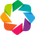

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [9]:
### Make a site map with satellite imagery in the background
gv.extension("bokeh")
site_map = (
    gv.tile_sources.EsriImagery.opts(width=700, height=450)
    * gdf.to_crs(epsg=4326).hvplot(
        geo=True,
        crs=ccrs.PlateCarree(),
        fill_alpha=0,
        line_color="yellow",
        line_width=2,
        title=f"HU12 Watershed {huc12}",
    )
)
site_map


## Watershed Context

This watershed (HUC12: 080902030506) is part of a larger hydrologic system defined by the USGS Watershed Boundary Dataset. 

The larger area appears to contain a mix of vegetated and developed land (to the west and north of the watershed boundary), with several other clusters corresponding to areas of dense/lush vegetation (within the watershed boundary) and others representing more sparsely vegetated or potentially developed surfaces (e.g., bare soil, buildings) around it. Given the regional context, it is likely that agricultural land use plays a role in shaping these patterns, along with natural vegetation. If you zoom in on the figure above it is clear we have a lot of water both in and outside the boundary. Noteably, the river to the west has very high turbidity, which is unsurprising given the amount of ships we can see. In comparison, the smaller ponds, rivers and lakes in the watershed boundary have less turbidity (clearer/darker).

Based specifcially on the HUC dataset description on ESRI (https://resilience.climate.gov/datasets/esri::watershed-boundary-dataset-huc-12s/about), HUC 12 corresponds to a subwatershed. This is also clear in the imagery as beyond the boundary area we have a quite a lot of other water bodies to the east. A subwatershed, "can be defined as smaller divisions within a watershed that collect and drain runoff through their own distinct outlets, playing a crucial role in the hydrological behavior and management of the larger watershed area." (https://www.sciencedirect.com/topics/agricultural-and-biological-sciences/subwatersheds) [Pradeep et al., 2024]

It would be useful to see the land classification types on site but that would require NLCD data. That would take a lot of time so the kmeans let us do some interpretation without that. I also do a test with the bands to essentially see if the number of clusters I picked are distinct enough, as we certainly have water and vegetation gradations.

## STEP 3: Multispectral data

### Step 3a: Search for data

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Log in to the <code>earthaccess</code> service using your Earthdata
credentials:
<code>python      earthaccess.login(persist=True)</code></li>
<li>Modify the following sample code to search for granules of the
HLSL30 product overlapping the watershed boundary from May to October
2023 (there should be 76 granules):
<code>python      results = earthaccess.search_data(          short_name="...",          cloud_hosted=True,          bounding_box=tuple(gdf.total_bounds),          temporal=("...", "..."),      )</code></li>
</ol></div></div>

### What my code is doing

In this step, I query NASA Earthdata using the `earthaccess` library to find satellite images (granules) that intersect the assigned study area and time range.

We then extract metadata for each granule, including:
- acquisition date and time
- tile ID
- file links for each spectral band

This creates a structured dataset that I will use to access and process the imagery.

In [10]:
### Log in to earthaccess
auth = earthaccess.login(persist=True)

In [11]:
### Search for HLS granules we want
results = earthaccess.search_data(

    ### specify which dataset and spatial resolution we want 
    short_name="HLSL30",

    ### specify that we're using cloud data
    cloud_hosted=True,

    ### use the bounding box from our watershed boundary
    bounding_box=tuple(gdf.to_crs(epsg=4326).total_bounds),

    ### set the temporal range of the data
    temporal=("2023-05-01", "2023-10-31"),
)
len(results)


88

### Step 3b: Compile information about each granule

I recommend building a GeoDataFrame, as this will allow you to plot the
granules you are downloading and make sure they line up with your
shapefile. You could also use a DataFrame, dictionary, or a custom
object to store this information.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>For each search result:
<ol type="1">
<li>Get the following information (HINT: look at the [‘umm’] values for
each search result):
<ul>
<li>granule id (UR)</li>
<li>datetime</li>
<li>geometry (HINT: check out the shapely.geometry.Polygon class to
convert points to a Polygon)</li>
</ul></li>
<li>Open the granule files. I recommend opening one granule at a time,
e.g. with (<code>earthaccess.open([result]</code>).</li>
<li>For each file (band), get the following information:
<ul>
<li>file handler returned from <code>earthaccess.open()</code></li>
<li>tile id</li>
<li>band number</li>
</ul></li>
</ol></li>
<li>Compile all the information you collected into a GeoDataFrame</li>
</ol></div></div>

In [36]:
### make a function to process all the granules from the earthaccess search
### and extract information for each granule

def process_granules(search_results):

    ### make and display a progress bar
    progress_bar = tqdm(total=len(search_results), desc="Compiling granule metadata")

    ### regex to extract tile id and band from HLS filenames
    tif_regex = re.compile(
        r"\.(?P<tile_id>\w+)\.\d+T\d+\.v\d\.\d\.(?P<band>[A-Za-z0-9]+)\.tif$",
        flags=re.IGNORECASE,
    )

    ### accumulate rows
    link_rows = []

    ### loop over granules
    for result in search_results:

        ### locate metadata
        umm = result["umm"]

        ### pull out granule id
        granule_id = umm.get("GranuleUR")

        ### extract datetime
        granule_datetime = pd.to_datetime(
            umm.get("TemporalExtent", {})
            .get("RangeDateTime", {})
            .get("BeginningDateTime")
        )

        ### extract boundary coordinates
        points = []
        try:
            gpolygons = (
                umm.get("SpatialExtent", {})
                .get("HorizontalSpatialDomain", {})
                .get("Geometry", {})
                .get("GPolygons", [])
            )

            if isinstance(gpolygons, dict):
                gpolygons = [gpolygons]

            if gpolygons:
                boundary = gpolygons[0].get("Boundary", [])
                if isinstance(boundary, dict):
                    boundary = [boundary]
                if boundary:
                    points = boundary[0].get("Points", [])

        except Exception as e:
            print(f"Could not extract polygon for {granule_id}: {e}")
            points = []

        ### make polygon
        if len(points) >= 3:
            geometry = Polygon([(pt["Longitude"], pt["Latitude"]) for pt in points])
        else:
            geometry = None

        ### THIS is the important part:
        ### open through earthaccess and keep the returned file-like objects
        try:
            granule_files = earthaccess.open([result])
        except Exception as e:
            print(f"Could not open granule {granule_id}: {e}")
            progress_bar.update(1)
            continue

        ### loop through each file object in the granule
        for file_obj in granule_files:
            file_match = tif_regex.search(file_obj.full_name)

            if file_match:
                link_rows.append(
                    {
                        "granule_id": granule_id,
                        "datetime": granule_datetime,
                        "geometry": geometry,
                        "url": file_obj,   # keep file-like object, not plain string
                        "tile_id": file_match.group("tile_id"),
                        "band": file_match.group("band"),
                    }
                )

        progress_bar.update(1)

    progress_bar.close()

    granule_gdf = gpd.GeoDataFrame(link_rows, geometry="geometry", crs="EPSG:4326")
    return granule_gdf

### Step 3c: Open, crop, and mask data

This will be the most resource-intensive step. I recommend caching your
results using the `cached` decorator or by writing your own caching
code. I also recommend testing this step with one or two dates before
running the full computation.

This code should include at least one **function** including a
numpy-style docstring. A good place to start would be a function for
opening a single masked raster, applying the appropriate scale
parameter, and cropping.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>For each granule:
<ol type="1">
<li><p>Open the Fmask band, crop, and compute a quality mask for the
granule. You can use the following code as a starting point, making sure
that <code>mask_bits</code> contains the quality bits you want to
consider: ```python # Expand into a new dimension of binary bits bits =
( np.unpackbits(da.astype(np.uint8), bitorder=‘little’)
.reshape(da.shape + (-1,)) )</p>
<p># Select the required bits and check if any are flagged mask =
np.prod(bits[…, mask_bits]==0, axis=-1) ```</p></li>
<li><p>For each band that starts with ‘B’:</p>
<ol type="1">
<li>Open the band, crop, and apply the scale factor</li>
<li>Name the DataArray after the band using the <code>.name</code>
attribute</li>
<li>Apply the cloud mask using the <code>.where()</code> method</li>
<li>Store the DataArray in your data structure (e.g. adding a
GeoDataFrame column with the DataArray in it. Note that you will need to
remove the rows for unused bands)</li>
</ol></li>
</ol></li>
</ol></div></div>

### What my code is doing

Here, I open each satellite image band, clip it to the watershed, and apply a cloud mask using the Fmask layer.

These steps ensures that:
- all data are spatially aligned to the study area
- cloudy or low-quality pixels are removed
- reflectance values are scaled properly

This produces a clean set of spectral data ready for analysis.

In this portion of the notebook I had to do quite a lot of debugging as I had an issue with an empty cache. You will see the @cached("masked_reflectance) commented out as the workflow functioned without it. This is also why rasterio.errors was imported here. You will also see a print summary block section in the code where I was trying to determine if rasters were being skipped or not. Even if you do not have bugs, this is a nice set of code to keep as it is a easy way to see if everything is working.

In [ ]:
from rasterio.errors import RasterioIOError

# @cached("masked_reflectance")   # leave off to avoid odd cache bug
def compute_reflectance_data(search_results, watershed_gdf):

    ### rebuild metadata inside function using earthaccess.open() file objects
    granule_gdf = process_granules(search_results)

    def open_crop_raster(file_obj, watershed_gdf, scale_factor=1.0, masked=True):
        try:
            da = rxr.open_rasterio(file_obj, masked=masked).squeeze(drop=True)
        except RasterioIOError as e:
            print(f"Open failed:\n{file_obj}\n{e}")
            return None
        except Exception as e:
            print(f"Unexpected open failure:\n{file_obj}\n{e}")
            return None

        try:
            watershed_on_da = watershed_gdf.to_crs(da.rio.crs)
            da = da.rio.clip_box(*watershed_on_da.total_bounds)
        except Exception as e:
            print(f"Clip failed:\n{file_obj}\n{e}")
            return None

        return da.astype("float32") * scale_factor

    def get_cloud_mask(fmask_da, mask_bits=(1, 2, 3)):
        bits = np.unpackbits(
            fmask_da.fillna(0).astype(np.uint8).values[..., np.newaxis],
            axis=-1,
            bitorder="little",
        )
        valid = np.prod(bits[..., list(mask_bits)] == 0, axis=-1).astype(bool)
        return xr.DataArray(valid, coords=fmask_da.coords, dims=fmask_da.dims)

    granule_da_rows = []

    total_groups = 0
    missing_fmask = 0
    failed_fmask_open = 0
    attempted_bands = 0
    failed_band_open = 0
    successful_bands = 0

    group_iter = granule_gdf.groupby(["datetime", "tile_id"])

    for (image_datetime, tile_id), tile_df in tqdm(group_iter, desc="Processing granules"):
        total_groups += 1

        fmask_df = tile_df.loc[tile_df.band.str.lower() == "fmask"]
        if fmask_df.empty:
            missing_fmask += 1
            continue

        fmask_da = open_crop_raster(
            fmask_df.iloc[0].url,
            watershed_gdf,
            scale_factor=1.0,
            masked=False,
        )

        if fmask_da is None:
            failed_fmask_open += 1
            continue

        clear_mask = get_cloud_mask(fmask_da)

        spectral_df = tile_df.loc[tile_df.band.str.upper().str.startswith("B")]

        for _, band_row in spectral_df.iterrows():
            attempted_bands += 1

            band_da = open_crop_raster(
                band_row.url,
                watershed_gdf,
                scale_factor=0.0001,
                masked=True,
            )

            if band_da is None:
                failed_band_open += 1
                continue

            band_da.name = band_row.band
            band_da = band_da.where(clear_mask)

            row_data = band_row.to_dict()
            row_data["da"] = band_da
            granule_da_rows.append(row_data)
            successful_bands += 1

    print("\nSummary")
    print("-------")
    print("Total datetime/tile groups:", total_groups)
    print("Groups missing Fmask row:", missing_fmask)
    print("Groups where Fmask failed to open:", failed_fmask_open)
    print("Band rasters attempted:", attempted_bands)
    print("Band rasters failed to open:", failed_band_open)
    print("Successful band rasters:", successful_bands)
    print("Rows appended:", len(granule_da_rows))

    if len(granule_da_rows) == 0:
        print("No valid rasters were processed; returning an empty GeoDataFrame.")
        empty_cols = list(granule_gdf.columns) + ["da"]
        return gpd.GeoDataFrame(
            {col: [] for col in empty_cols},
            geometry="geometry",
            crs=granule_gdf.crs
        )

    granule_da_df = pd.DataFrame(granule_da_rows)

    granule_da_gdf = gpd.GeoDataFrame(
        granule_da_df,
        geometry="geometry",
        crs=granule_gdf.crs
    )

    return granule_da_gdf

In [38]:
### apply the function
granule_da_gdf = compute_reflectance_data(results, gdf)

Compiling granule metadata:   0%|          | 0/88 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/15 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

...

QUEUEING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/15 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/15 [00:00<?, ?it/s]

Processing granules:   0%|          | 0/88 [00:00<?, ?it/s]

Unexpected open failure:
<File-like object HTTPFileSystem, https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2023268T163212.v2.0/HLS.L30.T15RYP.2023268T163212.v2.0.B01.tif>
403, message='Forbidden', url='https://d1nklfio7vscoe.cloudfront.net/s3-2d2df3a34830d5223d1e9547cd713408/lp-prod-protected.s3.us-west-2.amazonaws.com/HLSL30.020/HLS.L30.T15RYP.2023268T163212.v2.0/HLS.L30.T15RYP.2023268T163212.v2.0.B01.tif?A-userid=ecoward&backend_params=oA5A1SRpxhMpuzF+CKjoag==./bpQY1MMOdQ5Q8BS15cMTj/RNg+QSrzgG6n8z622Gd+vEdNXWAN27348gE8H3SSVbOYMy/lUI1fiqvghNvpEA1rRGY+PC7QeARnGab3S80yyI0byozQMCKC8tvvAWyLCOu3PUUaupkzgPqA3Z/UhiGAOD/6VWHw8kxd4FbL33EA2MWJiUF0/mlUdKpZ4/450nWVctdZXbJMjKnRWtji1eR1HbRFgFNgds2O/+bMMfja415fQydia+NsiLUujQ21DavPDbZwgl2avwRnnKRt8XMUAyXm+OpTbi5EdjJGHwkbnwylFvYuxbuu+EP1iThnamxHs/kVP8yPcq/W4i9GqOK9S0zoZAIH/6vYKPKyEmBaqHo/El8knwMTFoPy0fGwVmSn6vxNCkxWL452q2b1NkREZ2tdi/zNqwOHXcgQFovZuFZNk3CBQdmCo86Z6mC/xT0rx467Nk02XxjdawFjR1E5gAYPh9DCMoVALWvA+EARW0

In [39]:
print("Shape:", granule_da_gdf.shape)
print("Unique tiles:", granule_da_gdf["tile_id"].nunique())
print("Unique dates:", granule_da_gdf["datetime"].nunique())

Shape: (879, 7)
Unique tiles: 4
Unique dates: 22


In [40]:
granule_da_gdf["band"].value_counts()

band
B03    88
B02    88
B06    88
B09    88
B04    88
B10    88
B05    88
B11    88
B07    88
B01    87
Name: count, dtype: int64

In [41]:
### check out the dataframe
granule_da_gdf[["datetime", "tile_id", "band", "da"]].head()


,datetime,tile_id,band,da
0,2023-05-04 16:31:32.101000+00:00,T15RYN,B03,[[<xarray.DataArray 'B03' ()> Size: 4B\narray(...
1,2023-05-04 16:31:32.101000+00:00,T15RYN,B01,[[<xarray.DataArray 'B01' ()> Size: 4B\narray(...
2,2023-05-04 16:31:32.101000+00:00,T15RYN,B02,[[<xarray.DataArray 'B02' ()> Size: 4B\narray(...
3,2023-05-04 16:31:32.101000+00:00,T15RYN,B06,[[<xarray.DataArray 'B06' ()> Size: 4B\narray(...
4,2023-05-04 16:31:32.101000+00:00,T15RYN,B09,[[<xarray.DataArray 'B09' ()> Size: 4B\narray(...


### Step 3d: Merge and Composite Data

You will notice for this watershed that:   
1. The raster data for each date are spread across 4 granules  
2. Any given image is incomplete because of clouds

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">

*   1. For each band:  
    *   a. For each date:  
        *   i. Merge all 4 granules  
        *   ii. Mask any negative values created by interpolating from the nodata value of -9999 (`rioxarray`) should account for this, but doesn't appear to when merging. If you leave these values in, they will create problems later on
    *   b. Concatenate the merged DataArrays along a new date dimension  
    *   c. Take the mean in the date dimension to create a composite image that fills cloud gaps  
    *   d. Add the band as a dimensions, and give the DataArray a name  
*   2. Concatenate along the band dimension


### What my code is doing

In this step, I combine all spectral bands into a single data structure. Each pixel now has a vector of reflectance values across multiple wavelengths.

I did have 1 raster in one band have an error, so in band01, everything is based on 87/88. Since this only affected one band, there will be minimal impact on the rbg map and the kmeans map later. 

In [42]:
### apply cache decorator
@cached("composite_reflectance")

### create a function to merge and composite reflectance data from multiple granules
### end result: single, composite reflectance image for each spectral band
def merge_and_composite(granule_da_gdf):

    ### initialize a list to store dfs
    band_composites = []

    ### initialize a list to store composites after procesing
    spectral_bands = sorted(granule_da_gdf.band.unique())

    ### loop over each spectral band
    for band in spectral_bands:
        merged_das = []
        merged_dates = []
        band_df = granule_da_gdf.loc[granule_da_gdf.band == band]

        ### loop over date/time of image acquisition and merge granules for each data
        for image_datetime, date_df in band_df.groupby("datetime"):
            merged_da = rxrmerge.merge_arrays(list(date_df.da))

            ### mask negative values (could be no data or invalid data)
            merged_da = merged_da.where(merged_da >= 0)

            ### append to merged_das list we initialized
            merged_das.append(merged_da)
            merged_dates.append(pd.to_datetime(image_datetime))

        if not merged_das:
            continue

        ### composite images across dates
        merged_stack = xr.concat(merged_das, dim=pd.Index(merged_dates, name="datetime"))
        composite_da = merged_stack.mean(dim="datetime", skipna=True)
        composite_da = composite_da.expand_dims(band=[band])

        ### add processed and composite data array to lsit
        band_composites.append(composite_da)

    ### concatenates composite data arrays for each band along band dimension
    spectral_da = xr.concat(band_composites, dim="band").sortby("band")
    spectral_da.name = "reflectance"
    return spectral_da


### Note on the cells below [43, 48, 49] 

It looks like the array is empty but it is not. I added a extra print cell to better inspect the array to make sure everything was working properly. I then inspected the min and max values for each band to make sure everything was good there, and that there were no null values that I somehow did not account for in the earlier function.

In [43]:
### call function to get final composite reflectance data 
spectral_da = merge_and_composite(granule_da_gdf)
spectral_da


<xarray.DataArray 'reflectance' (band: 10, y: 556, x: 624)> Size: 14MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(10, 556, 624), dtype=float32)
Coordinates:
  * band         (band) object 80B 'B01' 'B02' 'B03' 'B04' ... 'B09' 'B10' 'B11'
  * y            (y) float64 4kB 3.304e+06 3.304e+06 ... 3.287e+06 3.287e+06
  * x            (x) float64 5kB 7.926e+05 7.926e+05 ... 8.112e+05 8.113e+05
    spatial_ref  int64 8B 0
Attributes: (12/35)
    ACCODE:                    Lasrc; Lasrc
    add_offset:                0.0
    arop_ave_xshift(meters):   0, 0
    arop_ave_yshift(meters):   0, 0
    arop_ncp:                  0, 0
    arop_rmse(meters):         0, 0
    ...                        ...
    TIRS_SSM_MODEL:            PRELIMINARY; PRELIMINARY
    TIRS_SSM_POSITION_STATUS:  ESTIMATED; ESTIMATED
    ULX:                       699960
    ULY:                       3300000
    USGS_SOFTWARE:             LPGS_16.2.0
    AREA_OR_POINT:             Area

In [48]:
print(spectral_da.shape)
print("Any nonzero?", bool((spectral_da != 0).any()))
print("Min:", float(spectral_da.min()))
print("Max:", float(spectral_da.max()))
print("Null count:", int(spectral_da.isnull().sum()))

(10, 556, 624)
Any nonzero? True
Min: 0.0
Max: 0.579759955406189
Null count: 0


In [49]:
for b in spectral_da.band.values:
    band = spectral_da.sel(band=b)
    print(
        b,
        "min=", float(band.min()),
        "max=", float(band.max()),
        "nonzero=", int((band != 0).sum()),
        "null=", int(band.isnull().sum()),
    )

B01 min= 0.0 max= 0.3458999991416931 nonzero= 317933 null= 0
B02 min= 0.0 max= 0.39754000306129456 nonzero= 317933 null= 0
B03 min= 0.0 max= 0.4569999575614929 nonzero= 317933 null= 0
B04 min= 0.0 max= 0.4811599850654602 nonzero= 317933 null= 0
B05 min= 0.0 max= 0.579759955406189 nonzero= 317933 null= 0
B06 min= 0.0 max= 0.5061999559402466 nonzero= 317933 null= 0
B07 min= 0.0 max= 0.2906000018119812 nonzero= 317933 null= 0
B09 min= 0.0 max= 0.005027272272855043 nonzero= 317933 null= 0
B10 min= 0.0 max= 0.29475000500679016 nonzero= 317933 null= 0
B11 min= 0.0 max= 0.2578499913215637 nonzero= 317933 null= 0


## STEP 4: K-means clustering

Cluster your data by spectral signature using the k-means algorithm.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Convert your DataArray into a <strong>tidy</strong> DataFrame of
reflectance values (hint: check out the <code>.to_dataframe()</code> and
<code>.unstack()</code> methods)</li>
<li>Filter out all rows with no data (all 0s or any N/A values)</li>
<li>Fit a k-means model. You can experiment with the number of groups to
find what works best.</li>
</ol></div></div>

### What my code is doing

I convert the multi-band raster data into a tabular format where:
- each row represents a pixel
- each column represents a spectral band

I also remove pixels with missing or zero values to ensure that the clustering algorithm receives clean input data.

In [51]:
### Convert spectral DataArray to a tidy DataFrame
model_df = (
    spectral_da.to_dataframe(name="reflectance")
    .reset_index()
    .pivot(index=["x", "y"], columns="band", values="reflectance")
)

### remove missing values
model_df = model_df.dropna()

### remove pixels where all bands are zero
model_df = model_df.loc[(model_df.sum(axis=1) > 0)]

model_df.head()

band                             B01       B02       B03       B04       B05  \
x             y                                                                
792568.062907 3.302583e+06  0.011041  0.011632  0.020750  0.013168  0.150445   
              3.302613e+06  0.010268  0.010873  0.019968  0.011936  0.154045   
              3.302643e+06  0.010500  0.011023  0.020032  0.011927  0.152514   
              3.302673e+06  0.010877  0.011377  0.019845  0.012155  0.149950   
              3.302703e+06  0.010523  0.010841  0.019432  0.011859  0.150114   

band                             B06       B07       B09       B10       B11  
x             y                                                               
792568.062907 3.302583e+06  0.068541  0.027827  0.000682  0.100150  0.088986  
              3.302613e+06  0.064605  0.025086  0.000614  0.099968  0.088873  
              3.302643e+06  0.065200  0.025691  0.000632  0.099832  0.088800  
              3.302673e+06  0.064200  0.025377  0.000627  0.099764  0.088782  
              3.302703e+06  0.063577  0.024800  0.000655  0.099805  0.088814

Now we're reading to fit the k-means clustering model. We can run the fit and prediction functions at the same time because we don't have target data.

### What my code is doing

Here, I apply k-means clustering to group pixels based on their spectral similarity.

The algorithm assigns each pixel to one of several clusters, where each cluster represents a distinct spectral pattern. These patterns often correspond to different land cover types (e.g., vegetation, water, built environments).

It is important to note that while I use 5 clusters, you could choose whatever you like. Keep in mind that the number of clusters affects how detailed the classification appears. You can change the value in the cell below (n_clusters=X) and rerun all the plotting cells to see how the clustering differs. You will see this difference in the kmeans map as the bar on the right will change based on the number of clusters specified. For example, there is a large difference between how granular a cluster of 5 v. 10 looks. Although how meaningful 10 clusters are here is questionable as it becomes really illegible. Similarly, more clusters than the actual number of land classification types on the site is not useful.   

In [87]:
### features only (no clusters column)
X = model_df.copy()

### initialize k-means model 
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init="auto")

### fit model and predict
cluster_labels = kmeans_model.fit_predict(X)

### add clusters back
model_df["clusters"] = cluster_labels

model_df.head()

band                             B01       B02       B03       B04       B05  \
x             y                                                                
792568.062907 3.302583e+06  0.011041  0.011632  0.020750  0.013168  0.150445   
              3.302613e+06  0.010268  0.010873  0.019968  0.011936  0.154045   
              3.302643e+06  0.010500  0.011023  0.020032  0.011927  0.152514   
              3.302673e+06  0.010877  0.011377  0.019845  0.012155  0.149950   
              3.302703e+06  0.010523  0.010841  0.019432  0.011859  0.150114   

band                             B06       B07       B09       B10       B11  \
x             y                                                                
792568.062907 3.302583e+06  0.068541  0.027827  0.000682  0.100150  0.088986   
              3.302613e+06  0.064605  0.025086  0.000614  0.099968  0.088873   
              3.302643e+06  0.065200  0.025691  0.000632  0.099832  0.088800   
              3.302673e+06  0.064200  0.025377  0.000627  0.099764  0.088782   
              3.302703e+06  0.063577  0.024800  0.000655  0.099805  0.088814   

band                        clusters  
x             y                       
792568.062907 3.302583e+06         2  
              3.302613e+06         2  
              3.302643e+06         2  
              3.302673e+06         2  
              3.302703e+06         2

### Bands and clusters

So since we cannot use NLCD data, I wanted to look at the values across bands (ignore the clusters column that is just there because I specified clusters already). We can see if there are any particularly high or low values across bands to help determine how we might classify our chosen clusters. I took a guess at 5 based on investigating the rgb map from earlier (which doesn't seem too far off based on the output below). Keep in mind we have 5 clusters here because I specified that earlier. Also when we map, these 5 clusters are much more distinct than 4. [Also the water on the map is much easier to see because it is all one color than different shades of color]

There are a couple bands to investigate:
- B04 (red)
- B05 (NIR) [vegetation]
- B06–B07 (SWIR) [do we have moisture?]

Based on the centering we can interpret the 5 clusters as follows: 
1. Cluster 0
    - This cluster seems to show healthy vegetation which is unsurprising given that the date range overlaps with spring. So we have some form of dense vegetation, but figuring out the composite of that is too hard to guess from the limited data we have. Probably a mix of irrigated land, forest and/or shrubery. 
    - B05 (NIR): 0.20  (high)
    - B04 (red): 0.035 (low)
2. Cluster 1
    - This one is the most different, but that is because this is likely to be all the water we saw on the rgb map. When you see the kmeans map later this is very clearly water.
    - B05: 0.053 (low)
    - B04: 0.046 (low)
    - All bands relatively low
3. Cluster 2
    - This cluster is much less dense than other clusters, so this may be bare soil or developed areas.
    - B05: 0.05 (low)
    - B04: 0.046 (low) 
4. Cluster 3
    - We've got more vegetation here, but it has more moisture. 
    - B05: 0.25 (very high)
    - B06/B07: higher than others (0, 1, 2)
5. Cluster 4
    - Again more vegetation but more dense. Difficult to tell what exact vegetation. 
    - B05: 0.31 (very high)

### Clarifying Bands vs Clusters

The bands (e.g., B01, B02, B03) represent different wavelengths of light measured by the satellite sensor. Each band captures a specific part of the electromagnetic spectrum, such as visible light or near-infrared.

The cluster numbers (e.g., 0, 1, 2, 3, 4) are not physical measurements. Instead, they are labels created by the k-means algorithm to group pixels with similar spectral characteristics. When we change the number of clusters in the kmeans section, the number of clusters under each band will change. Right now we have 5 clusters (0, 1, 2, 3, 4) but you could change it and rerun these cells to see what differences might pop up. 

In [88]:
### Some testing of how many clusters to use
# Ignore the cluster column
centers = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=model_df.columns
)
centers

band,B01,B02,B03,B04,B05,B06,B07,B09,B10,B11,clusters
0,0.019278,0.024356,0.047621,0.035577,0.203048,0.082600,0.039103,0.001270,0.238294,0.213957,1.703082e-13
1,0.026798,0.032196,0.050368,0.046639,0.053656,0.036420,0.027422,0.001078,0.227058,0.206091,2.000000e+00
2,0.023034,0.027419,0.050762,0.040082,0.254529,0.126553,0.060441,0.001121,0.216064,0.193561,3.000000e+00
3,0.014069,0.017883,0.030293,0.026373,0.041010,0.020046,0.013955,0.000883,0.185738,0.168162,1.000000e+00
4,0.023076,0.027856,0.055912,0.039395,0.315709,0.135347,0.060211,0.001344,0.241539,0.216274,2.000000e+00


## STEP 5: Plot

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Create a plot that shows the k-means clusters next to an RGB image of
the area. You may need to brighten your RGB image by multiplying it by
10. The code for reshaping and plotting the clusters is provided for you
below, but you will have to create the RGB plot yourself!</p>
<p>So, what is <code>.sortby(['x', 'y'])</code> doing for us? Try the
code without it and find out.</p></div></div>

### What my code is doing

In this final step, I visualize the clustering results alongside an RGB image of the same area.

Comparing the k-means clusters to the RGB image helps us interpret what each cluster represents in real-world terms. 

In [89]:
### make data array with bands to use for rgb: red, green, and blue
rgb_da = spectral_da.sel(band=["B04", "B03", "B02"]).sortby(["x", "y"]) * 10
rgb_plot = rgb_da.clip(min=0, max=1).hvplot.rgb(
    x="x",
    y="y",
    xlabel="Easting",
    ylabel="Northing",
    bands="band",
    aspect="equal",
)
rgb_plot


:RGB   [x,y]   (R,G,B)

In [90]:
cluster_xr = (
    model_df["clusters"]
    .to_xarray()
    .transpose("y", "x")
    .sortby("x")
    .sortby("y")
)

kmeans_plot = cluster_xr.hvplot(
    x="x",
    y="y",
    cmap="Colorblind",
    aspect="equal",
    xlabel="Easting",
    ylabel="Northing",
    width=500,
    height=500,
).opts(
    xrotation=45
)

(rgb_plot + kmeans_plot)

:Layout
   .RGB.I   :RGB   [x,y]   (R,G,B)
   .Image.I :Image   [x,y]   (clusters)

In [91]:
import holoviews as hv

final_plot = rgb_plot + kmeans_plot

hv.save(final_plot, "kmeans_rgb_comparison.html")

## Plot description

The k-means clustering map reveals several distinct spectral groupings that correspond to visible features in the RGB image. For example, one cluster appears to align with densely vegetated areas, showing higher reflectance in near-infrared bands [clusters 3/4 or pink and black on the kmeans map], while another cluster corresponds to darker surfaces such as water or shadowed regions [cluster 1 or yellow on the kmeans map]. We also have other healthy vegetation although not as dense or lush as cluster 3 [pink]. Cluster 0 and 2 [shades of blue] also indicate vegetation. 

Cluster 3 is the most interesting. I am assuming that these areas of the watershed have dried out a little and we have more marshy plants growing here, especially as they encircled or abutted by cluster 1 [yellow/water].

Some clusters are more difficult to interpret and may represent transitional areas or mixed land cover types. This includes the absence of any red and orange pixels on the kmeans map. This highlights a limitation of unsupervised classification, where clusters are defined mathematically rather than by predefined categories. So probably what has happened is these more transitional clusters have been subsumed into my 5 cluster categorization. When I did 10 clusters the map became more granular but also a lot more messy, so 5 seems to be a happy median. 

I realized I already did some analysis on the bands and clusters earlier so I have copied that same discussion below again.

### Bands and clusters

So since we cannot use NLCD data, I wanted to look at the values across bands (ignore the clusters column that is just there because I specified clusters already). We can see if there are any particularly high or low values across bands to help determine how we might classify our chosen clusters. I took a guess at 5 based on investigating the rgb map from earlier (which doesn't seem too far off based on the output below). Keep in mind we have 5 clusters here because I specified that earlier. Also when we map, these 5 clusters are much more distinct than 4. [Also the water on the map is much easier to see because it is all one color than different shades of color]

There are a couple bands to investigate:
- B04 (red)
- B05 (NIR) [vegetation]
- B06–B07 (SWIR) [do we have moisture?]

Based on the centering we can interpret the 5 clusters as follows: 
1. Cluster 0
    - This cluster seems to show healthy vegetation which is unsurprising given that the date range overlaps with spring. So we have some form of dense vegetation, but figuring out the composite of that is too hard to guess from the limited data we have. Probably a mix of irrigated land, forest and/or shrubery. 
    - B05 (NIR): 0.20  (high)
    - B04 (red): 0.035 (low)
2. Cluster 1
    - This one is the most different, but that is because this is likely to be all the water we saw on the rgb map. When you see the kmeans map later this is very clearly water.
    - B05: 0.053 (low)
    - B04: 0.046 (low)
    - All bands relatively low
3. Cluster 2
    - This cluster is much less dense than other clusters, so this may be bare soil or developed areas.
    - B05: 0.05 (low)
    - B04: 0.046 (low) 
4. Cluster 3
    - We've got more vegetation here, but it has more moisture. 
    - B05: 0.25 (very high)
    - B06/B07: higher than others (0, 1, 2)
5. Cluster 4
    - Again more vegetation but more dense. Difficult to tell what exact vegetation. 
    - B05: 0.31 (very high)